<a href="https://colab.research.google.com/github/trewto/Machine-Learning-Models/blob/main/PredictExpenseTypev2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score


In [2]:
file_path = '/content/drive/My Drive/Projects/ExpensetypePrediction/formltraining_expenselist.csv'
data = pd.read_csv(file_path)


In [ ]:
data.head()

In [ ]:
new_data = data[["description","Type"]]
new_data.head()


**Process with null data**

In [ ]:
# prompt: i want to see the number of missing value in description and Type and also want to see the unique Types

print(new_data.isnull().sum())
print(new_data['Type'].unique())


In [6]:
new_data = new_data.dropna()
new_data.isnull().sum()

,0
description,0
Type,0


In [10]:

new_data['Type'] = new_data['Type'].str.upper()

new_data.head()

,description,Type
1,auto,TRANSPORTATION
2,rikshaw baba ami shaplay khawoua,NASTA
3,( + ovi 200:) ami ovi apri kitchen a nachos ar...,TREAT
4,auto,TRANSPORTATION
5,cha,TREAT


In [ ]:
# prompt: I want to see the numbers of each unique type

new_data['Type'].value_counts()


In [12]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Convert descriptions to TF-IDF features
vectorizer = TfidfVectorizer(max_features=1000)  # Adjust max_features as needed
X = vectorizer.fit_transform(new_data['description']).toarray()

# Encode the target variable 'Type'
y = new_data['Type'].astype('category').cat.codes


In [ ]:
# prompt: i want to know which vector represent what

feature_names = vectorizer.get_feature_names_out()
print(feature_names)


In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [15]:
# prompt: i want to know the number where y_test  ="rent"

(y_test == 3).sum()


23

In [55]:
model = RandomForestClassifier(n_estimators=100, random_state=22)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))


Accuracy: 0.7765567765567766


In [56]:
# prompt: create kn model

from sklearn.neighbors import KNeighborsClassifier

model = KNeighborsClassifier(n_neighbors=5)  # You can adjust the number of neighbors
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))



Accuracy: 0.7326007326007326


In [57]:
from sklearn.svm import SVC
model = SVC()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))


Accuracy: 0.73992673992674


In [58]:
import xgboost as xgb
model = xgb.XGBClassifier()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))


Accuracy: 0.7106227106227107


In [59]:
from sklearn.naive_bayes import MultinomialNB
model = MultinomialNB()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))


Accuracy: 0.6776556776556777


In [60]:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))


Accuracy: 0.7582417582417582


In [62]:
from sklearn.neural_network import MLPClassifier
model = MLPClassifier(hidden_layer_sizes=(1000,1000), max_iter=500)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))


Accuracy: 0.7655677655677655


In [63]:
from sklearn.ensemble import AdaBoostClassifier
model = AdaBoostClassifier(n_estimators=100)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))


/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


Accuracy: 0.27106227106227104


In [65]:
from sklearn.ensemble import ExtraTreesClassifier
model = ExtraTreesClassifier()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))


Accuracy: 0.8021978021978022


In [66]:
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.8021978021978022
Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.25      0.50      0.33         2
           2       1.00      0.25      0.40         4
           3       0.92      0.96      0.94        23
           4       0.97      0.86      0.91        43
           6       1.00      1.00      1.00         2
           7       0.73      0.66      0.69        29
           8       1.00      0.62      0.76        13
           9       0.00      0.00      0.00         1
          10       0.38      0.83      0.52        18
          11       1.00      1.00      1.00         1
          12       0.50      0.25      0.33         4
          13       0.00      0.00      0.00         2
          14       0.85      0.76      0.80        37
          17       0.82      0.69      0.75        13
          19       1.00      1.00      1.00         2
          20       1.00     

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [67]:
import joblib
joblib.dump(model, '/content/drive/My Drive/Projects/ExpensetypePrediction/expense_type_model.pkl')


['/content/drive/My Drive/Projects/ExpensetypePrediction/expense_type_model.pkl']

In [68]:
# Example description to predict
new_description = ["rikshaw"]

# Transform the description using the same TF-IDF vectorizer
new_description_transformed = vectorizer.transform(new_description).toarray()

# Predict the type using the trained model
predicted_type_code = model.predict(new_description_transformed)

# Convert the predicted type code back to the original label
predicted_type = new_data['Type'].astype('category').cat.categories[predicted_type_code][0]

print(f"The predicted type for 'rikshaw' is: {predicted_type}")


The predicted type for 'rikshaw' is: TRANSPORTATION


In [69]:
# Predict the types for the test data
y_pred = model.predict(X_test)

# Convert the codes back to the original labels
category_mapping = dict(enumerate(new_data['Type'].astype('category').cat.categories))
actual_types = pd.Series(y_test).map(category_mapping).tolist()
predicted_types = pd.Series(y_pred).map(category_mapping).tolist()

# Since y_test is a numpy array, we need to get the correct descriptions from X_test
# Assuming X_test is derived from vectorized data, we need to trace back to the original descriptions
# Here we assume that X_test comes from a subset of data, so we'll use the original indices from the split

# Get the original descriptions using the same indices used for X_test
original_descriptions = data.iloc[y_test.index]['description'].values

# Create a DataFrame to hold descriptions, actual types, and predicted types
results_df = pd.DataFrame({
    'Description': original_descriptions,
    'Actual Type': actual_types,
    'Predicted Type': predicted_types
})

# Display the first few rows of the results
print(results_df.head(2))


                      Description     Actual Type  Predicted Type
0                        recharge        RECHARGE        RECHARGE
1  rikshaw polashi to buet mosque  TRANSPORTATION  TRANSPORTATION


In [70]:
# Check the distribution of types in the training set
train_type_distribution = pd.Series(y_train).map(category_mapping).value_counts()
print("Training set distribution:\n", train_type_distribution)

# Check the distribution of types in the test set
test_type_distribution = pd.Series(y_test).map(category_mapping).value_counts()
print("Test set distribution:\n", test_type_distribution)


Training set distribution:
 TRANSPORTATION    199
NASTA             165
COLDDRINK         164
FASTFOOD          136
CHA                73
ITEM               70
FOOD               64
RECHARGE           52
TREAT              49
WATER              20
BREAKFAST          17
STATIONARY         12
MEDICINE           12
PRINT              10
SHARED_RENTAL       7
BUET_FEE            7
GIFT                6
RENT                5
PHOTOCOPY           5
MA                  4
SELUN               4
DHAR                3
TOUR                3
DAD                 2
BOOK                2
METRO_RECHARGE      1
Name: count, dtype: int64
Test set distribution:
 TRANSPORTATION    54
COLDDRINK         43
NASTA             37
FASTFOOD          29
CHA               23
ITEM              18
TREAT             14
RECHARGE          13
FOOD              13
WATER              5
MEDICINE           4
BUET_FEE           4
METRO_RECHARGE     2
DHAR               2
TOUR               2
SELUN              2
SHARED_RENTAL 

**Plot confusion Matrix and Accuracy**

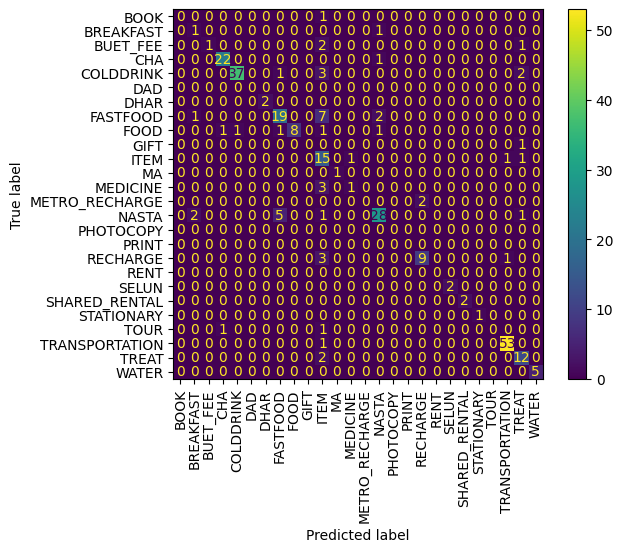

In [71]:
# prompt: please generate me a confusion matrix with type name

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Generate the confusion matrix
cm = confusion_matrix(actual_types, predicted_types, labels=list(category_mapping.values()))

# Create the ConfusionMatrixDisplay object
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(category_mapping.values()))

# Plot the confusion matrix
disp.plot(xticks_rotation='vertical')
plt.show()


In [72]:
# prompt: print the accuracy rate

print(f"Accuracy: {accuracy_score(y_test, y_pred)}")


Accuracy: 0.8021978021978022


**Predict Single Description**

In [73]:
# prompt: predict the type for a description "riksshaw fare"

# Example description to predict
new_description = ["juice"]

# Transform the description using the same TF-IDF vectorizer
new_description_transformed = vectorizer.transform(new_description).toarray()

# Predict the type using the trained model
predicted_type_code = model.predict(new_description_transformed)

# Convert the predicted type code back to the original label
predicted_type = new_data['Type'].astype('category').cat.categories[predicted_type_code][0]

print(f"The predicted type for is: {predicted_type}")



The predicted type for is: COLDDRINK


**Print Multiple Data**

In [75]:
# Example descriptions
new_descriptions = ["juice", "rikshaw", "dinning fee"]

# Transform the descriptions using the same TF-IDF vectorizer
new_descriptions_transformed = vectorizer.transform(new_descriptions).toarray()

# Predict the types using the trained model
predicted_type_codes = model.predict(new_descriptions_transformed)

# Convert the predicted type codes back to the original labels
class_labels = new_data['Type'].astype('category').cat.categories
predicted_types = [class_labels[code] for code in predicted_type_codes]

# Display predictions
for description, predicted_type in zip(new_descriptions, predicted_types):
    print(f"The predicted type for '{description}' is: {predicted_type}")

The predicted type for 'juice' is: COLDDRINK
The predicted type for 'rikshaw' is: TRANSPORTATION
The predicted type for 'dinning fee' is: BUET_FEE


In [76]:
# prompt: now i want to predicit the description "rikshaw kore pepsi khete jabo"

# Example description to predict
new_description = ["bus"]

# Transform the description using the same TF-IDF vectorizer
new_description_transformed = vectorizer.transform(new_description).toarray()

# Predict the type using the trained model
predicted_type_code = model.predict(new_description_transformed)

# Convert the predicted type code back to the original label
predicted_type = new_data['Type'].astype('category').cat.categories[predicted_type_code][0]

print(f"The predicted type for description: {new_description} is: {predicted_type}")


The predicted type for description: ['bus'] is: TRANSPORTATION
